In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import datasets

(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print(f"Date antrenare CIFAR: {X_train.shape}")
print(f"Etichete antrenare: {y_train.shape}")

Date antrenare CIFAR: (50000, 32, 32, 3)
Etichete antrenare: (50000, 1)


In [2]:
from tensorflow.keras import layers, models, optimizers

def create_advanced_cifar_model():
    model = models.Sequential([
    
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.2),

    
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        #detalii fine de textura
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.4),

       
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])
    
    model.compile(
        optimizer=optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

cifar_model = create_advanced_cifar_model()
cifar_model.summary()

c:\Users\User1\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 404,778 (1.54 MB)

 Trainable params: 403,882 (1.54 MB)

 Non-trainable params: 896 (3.50 KB)

In [3]:
history_cifar = cifar_model.fit(
    X_train, y_train, 
    epochs=12, 
    batch_size=64, 
    validation_data=(X_test, y_test)
)

Epoch 1/12
782/782 ━━━━━━━━━━━━━━━━━━━━ 121s 147ms/step - accuracy: 0.4284 - loss: 1.6750 - val_accuracy: 0.5409 - val_loss: 1.3122
Epoch 2/12
782/782 ━━━━━━━━━━━━━━━━━━━━ 138s 142ms/step - accuracy: 0.6057 - loss: 1.1125 - val_accuracy: 0.6626 - val_loss: 0.9622
Epoch 3/12
782/782 ━━━━━━━━━━━━━━━━━━━━ 116s 148ms/step - accuracy: 0.6717 - loss: 0.9362 - val_accuracy: 0.6977 - val_loss: 0.8606
Epoch 4/12
782/782 ━━━━━━━━━━━━━━━━━━━━ 112s 144ms/step - accuracy: 0.7032 - loss: 0.8454 - val_accuracy: 0.6770 - val_loss: 0.9008
Epoch 5/12
782/782 ━━━━━━━━━━━━━━━━━━━━ 113s 145ms/step - accuracy: 0.7307 - loss: 0.7811 - val_accuracy: 0.7141 - val_loss: 0.8205
Epoch 6/12
782/782 ━━━━━━━━━━━━━━━━━━━━ 140s 143ms/step - accuracy: 0.7456 - loss: 0.7349 - val_accuracy: 0.7601 - val_loss: 0.6836
Epoch 7/12
782/782 ━━━━━━━━━━━━━━━━━━━━ 111s 142ms/step - accuracy: 0.7603 - loss: 0.6949 - val_accuracy: 0.7691 - val_loss: 0.6628
Epoch 8/12
782/782 ━━━━━━━━━━━━━━━━━━━━ 144s 145ms/step - accuracy: 0.7727 -

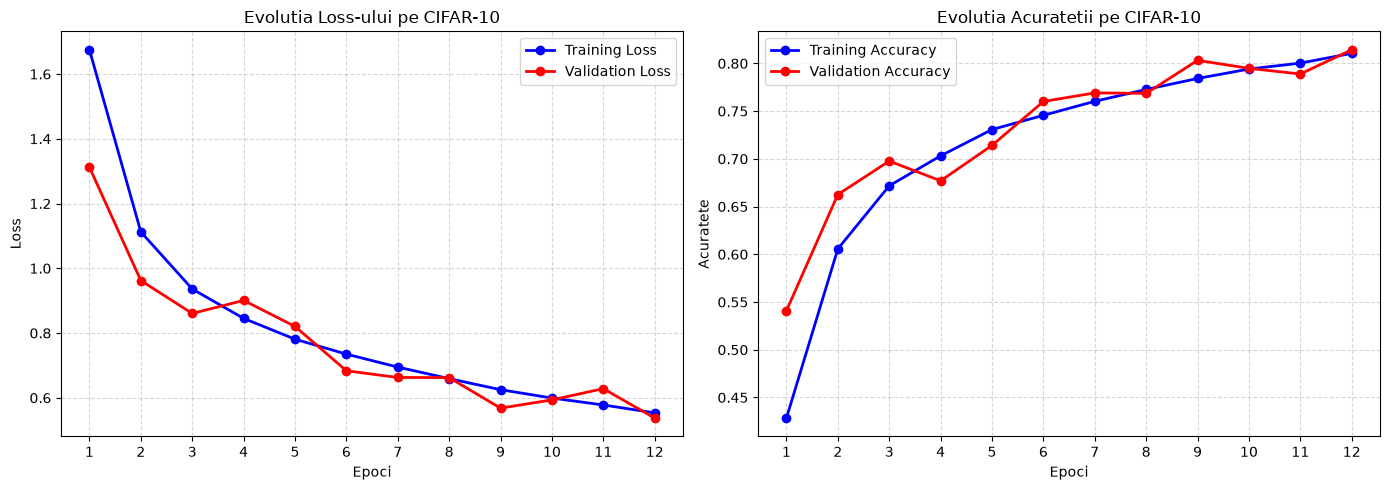

In [4]:
import matplotlib.pyplot as plt


train_loss = history_cifar.history['loss']
val_loss = history_cifar.history['val_loss']
train_acc = history_cifar.history['accuracy']
val_acc = history_cifar.history['val_accuracy']
epochs_range = range(1, len(train_loss) + 1)

plt.figure(figsize=(14, 5))

#Eroarea
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_loss, 'b-o', label='Training Loss', linewidth=2)
plt.plot(epochs_range, val_loss, 'r-o', label='Validation Loss', linewidth=2)
plt.title('Evolutia Loss-ului pe CIFAR-10')
plt.xlabel('Epoci')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(epochs_range)
plt.legend()

# Acuratetea 
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_acc, 'b-o', label='Training Accuracy', linewidth=2)
plt.plot(epochs_range, val_acc, 'r-o', label='Validation Accuracy', linewidth=2)
plt.title('Evolutia Acuratetii pe CIFAR-10')
plt.xlabel('Epoci')
plt.ylabel('Acuratete')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(epochs_range)
plt.legend()

plt.tight_layout()
plt.show()

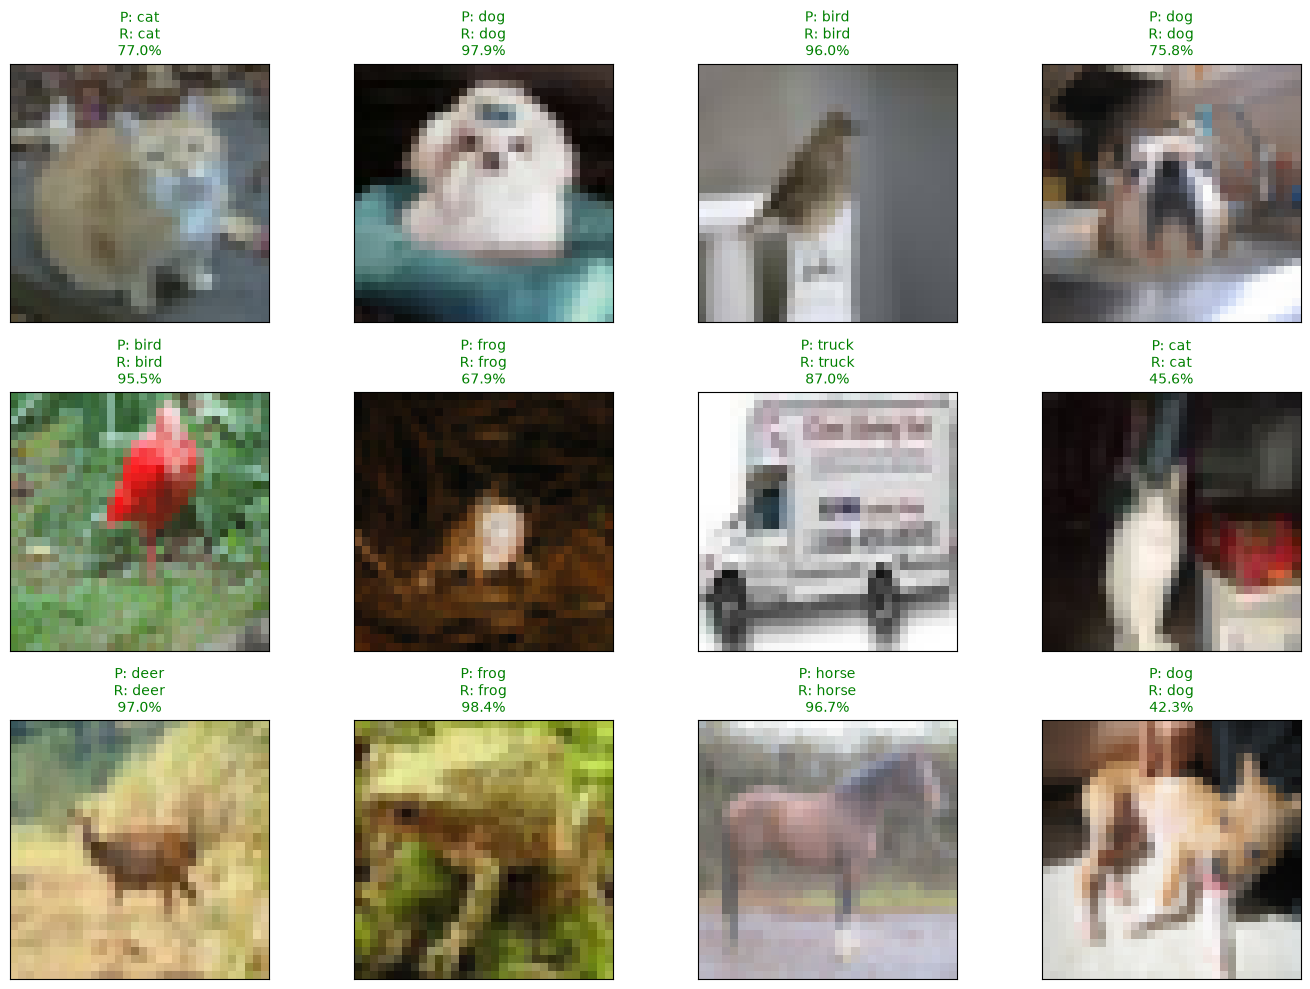

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import random

cifar10_classes = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

nr_imagini = 12

fig, axes = plt.subplots(3, 4, figsize=(14, 10))

for ax in axes.flat:

    idx = random.randint(0, len(X_test)-1)

    sample_image = X_test[idx]
    true_label = int(y_test[idx][0])

    prediction = cifar_model.predict(
        np.expand_dims(sample_image, axis=0),
        verbose=0
    )[0]

    pred_label = np.argmax(prediction)
    confidence = prediction[pred_label] * 100

    culoare = "green" if pred_label == true_label else "red"

    ax.imshow(sample_image)
    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_title(
        f"P: {cifar10_classes[pred_label]}\n"
        f"R: {cifar10_classes[true_label]}\n"
        f"{confidence:.1f}%",
        color=culoare,
        fontsize=10
    )

plt.tight_layout()
plt.show()